In [6]:
import numpy as np 
import pandas as pd 
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu,wilcoxon
import gzip 
import re




In [11]:
tvrs = pd.read_csv('data_for_submission/quantification_of_tvr_duplications.csv')
canonical_arms = [
    f"chr{i}{arm}" for i in range(1, 23) for arm in ("p", "q")
] + ["chrXp", "chrXq"]
tvrs[['chrom_arm', 'haplotype_id']] = tvrs['chrom'].str.split(':', expand=True)
tvrs = tvrs[tvrs.note!='ancestral']

--------------------------------------------------
AVERAGE VALUES (in kb)
--------------------------------------------------
Size of TVR barcode that is repeated (1st code): 0.667 kb
Distance between repeated barcodes (2nd start - 1st end): 0.239 kb
Distance between repeated barcodes (2nd start - 1st start): 0.906 kb
Dist. of 1st duplication start from telomere boundary: 0.553 kb
Dist. of 1st duplication midpoint from telomere boundary: 0.886 kb
Midpoint between 2 duplications (between 1st end and 2nd start): 1.340 kb


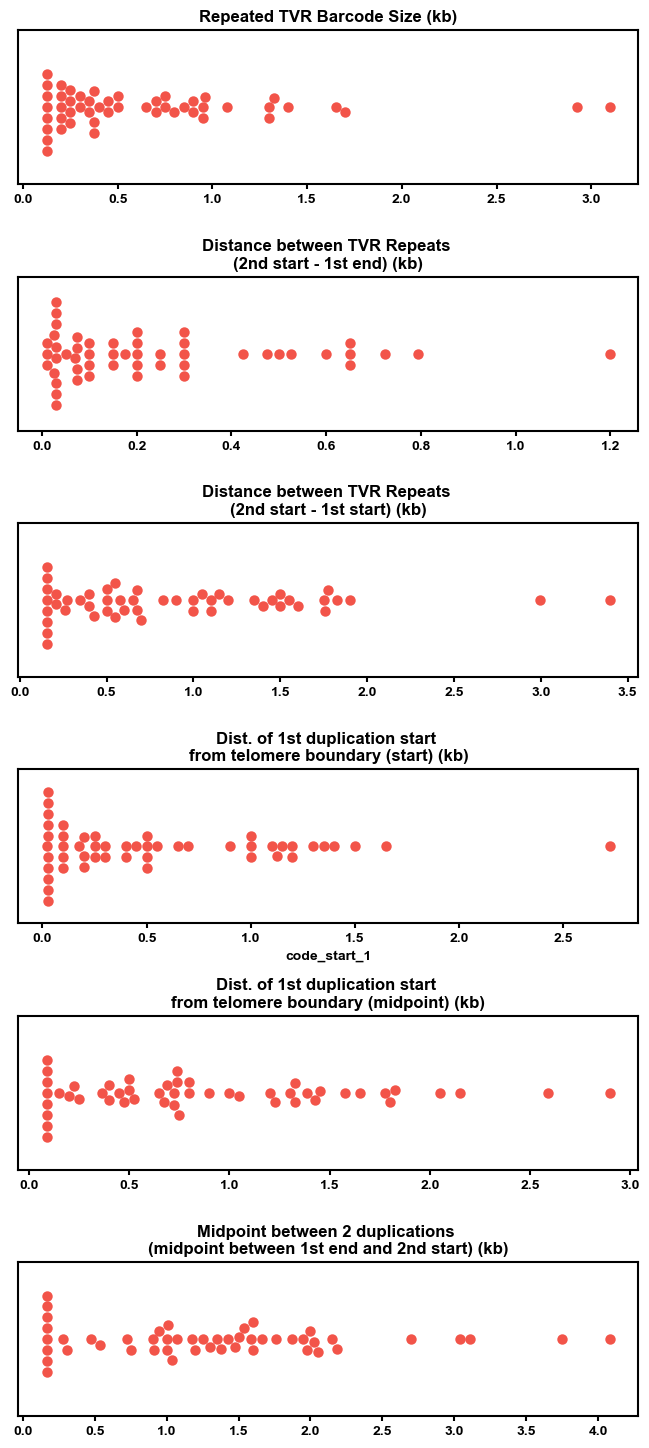

In [12]:


# Set global font properties to Arial Bold
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# Set line widths to 0.5 points (equivalent to Illustrator 0.5 stroke)
stroke_width = 1.5
plt.rcParams['axes.linewidth'] = stroke_width
plt.rcParams['xtick.major.width'] = stroke_width
plt.rcParams['ytick.major.width'] = stroke_width
plt.rcParams['xtick.minor.width'] = stroke_width
plt.rcParams['ytick.minor.width'] = stroke_width
plt.rcParams['lines.linewidth'] = stroke_width

# Set aesthetics for the points
s = 7.5
point_color = '#F25449' # A custom mix between salmon and red

# Adjust figsize for a stacked, multi-subplot layout (width, height)
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(8, 18), sharex=False)
plt.subplots_adjust(hspace=0.6) # Add some space between plots for the titles

# 1. Repeated TVR Barcode Size (kb)
data1 = (tvrs.code_end_1 - tvrs.code_start_1) / 1000.0
sns.swarmplot(x=data1, s=s, color=point_color, ax=axes[0])
axes[0].set_title('Repeated TVR Barcode Size (kb)')
val1 = np.nanmean(data1)

# 2. Distance between TVR Repeats (2nd start - 1st end) (kb)
data2 = (tvrs.code_start_2 - tvrs.code_end_1) / 1000.0
sns.swarmplot(x=data2, s=s, color=point_color, ax=axes[1])
axes[1].set_title('Distance between TVR Repeats \n(2nd start - 1st end) (kb)')
val2 = np.nanmean(data2)

# 3. Distance between TVR Repeats (2nd start - 1st start) (kb)
data3 = (tvrs.code_start_2 - tvrs.code_start_1) / 1000.0
sns.swarmplot(x=data3, s=s, color=point_color, ax=axes[2])
axes[2].set_title('Distance between TVR Repeats \n(2nd start - 1st start) (kb)')
val3 = np.nanmean(data3)

# 4. Dist. of 1st duplication start from telomere boundary (kb)
data4 = tvrs.code_start_1 / 1000.0
sns.swarmplot(x=data4, s=s, color=point_color, ax=axes[3])
axes[3].set_title('Dist. of 1st duplication start \nfrom telomere boundary (start) (kb)')
val4 = np.nanmean(data4)

# 5. Dist. of 1st duplication midpoint from telomere boundary (kb)
data5 = ((tvrs.code_start_1 + tvrs.code_end_1) / 2) / 1000.0
sns.swarmplot(x=data5, s=s, color=point_color, ax=axes[4])
axes[4].set_title('Dist. of 1st duplication start \nfrom telomere boundary (midpoint) (kb)')
val5 = np.nanmean(data5)

# 6. Midpoint between 2 duplications (kb)
data6 = ((tvrs.code_end_1 + tvrs.code_start_2) / 2) / 1000.0
sns.swarmplot(x=data6, s=s, color=point_color, ax=axes[5])
axes[5].set_title('Midpoint between 2 duplications \n(midpoint between 1st end and 2nd start) (kb)')
val6 = np.nanmean(data6)

# Remove y-axis labels/ticks since it's a 1D horizontal plot
for ax in axes:
    ax.set_yticks([])
    ax.set_ylabel('')

# Save or show
# plt.show()

# Print all values at the end
print("-" * 50)
print("AVERAGE VALUES (in kb)")
print("-" * 50)
print(f'Size of TVR barcode that is repeated (1st code): {val1:.3f} kb')
print(f'Distance between repeated barcodes (2nd start - 1st end): {val2:.3f} kb')
print(f'Distance between repeated barcodes (2nd start - 1st start): {val3:.3f} kb')
print(f'Dist. of 1st duplication start from telomere boundary: {val4:.3f} kb')
print(f'Dist. of 1st duplication midpoint from telomere boundary: {val5:.3f} kb')
print(f'Midpoint between 2 duplications (between 1st end and 2nd start): {val6:.3f} kb')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [01:36<00:00,  2.54s/it]


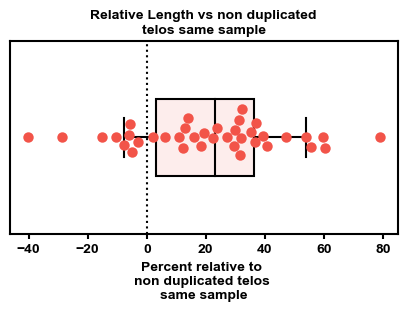

--------------------------------------------------
LENGTH STATISTICS
--------------------------------------------------
Median change in relative length of duplicated telomeres: 23.120
Median change in absolute length of duplicated telomeres: 1258.500
Median change significance with Wilcoxon test (p-value): 1.74e-05
Proportion of all duplication events that occurs on chr19p
0.2
Number of arms that contain duplication event
23
Proportion of haplotypes with an event:
0.37254901960784315


In [10]:
import matplotlib.colors as mcolors    

chrom_alias = pd.read_csv('data_for_submission/all_diploid_alias.txt',
                          sep="\t",
                          header=None,
                          names=['id','chrom','contig']
                         )

id_to_chr = dict(zip(chrom_alias['id'], chrom_alias['chrom']))

def read_in_tsv(file,id_to_chr):
    
    col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         '5mC_pos',
         '5mC_score',
         'query_sequence']
    
    
    
    sample_id = file.split('.')[0].split('/')[-1]
    sample_tsv = pd.read_csv(file,sep="\t",index_col=False,header=None,
                        usecols = [0,1,2,3,4,5,6,7,8,9,10,11,14,15,21],names=col_names,skiprows=1)
    
    sample_id = file.split('.')[0]

    sample_tsv['chr_base'] = sample_tsv['chrom'].map(id_to_chr)

    threshold = 100_000
    sample_tsv['chrom_assignment'] = (
        sample_tsv['chr_base'] + np.where(sample_tsv['centering_position'].astype(int) > threshold, 'q', 'p')
    )

    sample_tsv.drop(columns=['chr_base'], inplace=True)

    return sample_tsv

ont_prefix = 'data_for_submission/centered_reads_phred20_filtered/ont/*.telo_center.txt.gz'

hap_list = tvrs["haplotype_id"].unique().tolist()

dup_lens = []
non_dup_lens = []


for label in tqdm(hap_list):
    
    file_name = f'data_for_submission/centered_reads_phred20_filtered/ont/{label[:-2]}.telo_center.txt.gz'
    
    label_tsv = read_in_tsv(file_name,id_to_chr)
    
    chroms_to_check = tvrs.chrom[tvrs.haplotype_id==label].unique().tolist()
    
    chroms_to_check =[x.split(":")[0] for x in chroms_to_check]
    
    parts = label_tsv["chrom"].astype(str).str.split("#", n=2, expand=True)
    label_tsv["individual"] = parts[0]                         
    label_tsv["individual_hap"] = parts[1]     
    label_tsv["individual_contig"] = parts[2]                     
    
    all_idxs = []
    
    label_ind = label.split(":")[0].split("_")[0]
    
    label_hap = label.split(":")[0].split("_")[1]
    
    # get idx of all telomere molecules within that hap and individual
    idx = (label_tsv.individual == label_ind) & (label_tsv.individual_hap == label_hap) & (np.isin(label_tsv.chrom_assignment,chroms_to_check))
    
    # split the telomere moelcules from that individual to those 
    # with and without a tvr duplication (by arm)
    dup_lens.append(label_tsv.centered_query_end[idx].tolist())
    non_dup_lens.append(label_tsv.centered_query_end[~idx].tolist())

relative_lens = []

relative_lens_absolute = []
for d,nd in zip(dup_lens,non_dup_lens):
    # we can now look at the median length of the telomeric portion of those molecule 
    # with a tvr duplication and those without one, and calculate the relative percent change in 
    # molecular telomere lenght relative to the median length of telomere molecules in that sample and haplotype
    relative_lens.append((100 * (np.nanmedian(d)/np.nanmedian(nd)) - 100))
    relative_lens_absolute.append(np.nanmedian(d) - np.nanmedian(nd))
relative_lens_arr = np.array(relative_lens)


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

stroke_width = 1.5
plt.rcParams['axes.linewidth'] = stroke_width
plt.rcParams['xtick.major.width'] = stroke_width
plt.rcParams['ytick.major.width'] = stroke_width
plt.rcParams['xtick.minor.width'] = stroke_width
plt.rcParams['ytick.minor.width'] = stroke_width
plt.rcParams['lines.linewidth'] = stroke_width

s = 7.5
point_color = '#F25449' # Custom mix between salmon and red

box_fill_color = mcolors.to_rgba(point_color, alpha=0.1)

plt.figure(figsize=(5, 2.5)) 

plt.title('Relative Length vs non duplicated\ntelos same sample', fontsize=10)
plt.xlabel('Percent relative to \nnon duplicated telos \nsame sample')

plt.axvline(0, ls='dotted', lw=stroke_width, c='black', zorder=0)

plt.boxplot(
    relative_lens_arr[np.isfinite(relative_lens_arr)],
    vert=False,
    whis=(10, 90),
    sym="",
    positions=[0],
    widths=0.4,
    patch_artist=True,
    zorder=1,
    boxprops=dict(linewidth=stroke_width, color='black', facecolor=box_fill_color),
    whiskerprops=dict(linewidth=stroke_width, color='black'),
    capprops=dict(linewidth=stroke_width, color='black'),
    medianprops=dict(linewidth=stroke_width, color='black')
)


sns.swarmplot(x=relative_lens, s=s, color=point_color, alpha=1.0, zorder=2)

plt.yticks([])
plt.show()


print("-" * 50)
print("LENGTH STATISTICS")
print("-" * 50)
print(f'Median change in relative length of duplicated telomeres: {np.nanmedian(relative_lens):.3f}')
print(f'Median change in absolute length of duplicated telomeres: {np.nanmedian(relative_lens_absolute):.3f}')

# Wilcoxon Test
stat, p = wilcoxon(relative_lens_arr[np.isfinite(relative_lens_arr)])
print(f'Median change significance with Wilcoxon test (p-value): {p:.2e}')


print('Proportion of all duplication events that occurs on chr19p')
print(sum(tvrs.chrom_arm=='chr19p')/len(tvrs))

print('Number of arms that contain duplication event')
print(len(np.unique(tvrs.chrom_arm)))

print('Proportion of haplotypes with an event:')
print(len(np.unique(tvrs.haplotype_id)) / 102) # 51 R10 ONT samples, so 102 total haplotypes